=== Best Parameters and Score for Each Model ===

1. XGBoost
Best Params: {'learning_rate': 0.05, 'n_estimators': 200}
Best CV Score (Negative RMSE): -8.455739799026702

2. CatBoost
Best Params: {'depth': 5, 'learning_rate': 0.05}
Best CV Score (Negative RMSE): -7.669025629531252

3. RandomForest
Best Params: {'max_depth': 10, 'n_estimators': 100}
Best CV Score (Negative RMSE): -7.916067519495354

4. MLP
Best Params: {'hidden_layer_sizes': (64, 32, 16), 'learning_rate_init': 0.005, 'max_iter': 200}
Best CV Score (Negative RMSE): -7.44750704473167


RMSE: 6.2400922930573515
MAE: 4.215379941851813
R2 Score: 0.9476167409877987
MRE (Mean Relative Error): 6.90%



=== Best Parameters and Score for Each Model ===

1. XGBoost
Best Params: {'learning_rate': 0.06, 'max_depth': 6, 'n_estimators': 400, 'subsample': 0.8}
Best CV Score (Negative RMSE): -6.5146322185397585

2. CatBoost
Best Params: {'depth': 7, 'iterations': 300, 'l2_leaf_reg': 1, 'learning_rate': 0.06}
Best CV Score (Negative RMSE): -8.107498132936325

3. RandomForest
Best Params: {'max_depth': 14, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score (Negative RMSE): -6.692249490597942

4. MLP
Best Params: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.003, 'max_iter': 300}
Best CV Score (Negative RMSE): -7.261667535302286



RMSE: 6.043093940824797
MAE: 3.7008425958770874
R2 Score: 0.9508719892699545
MRE (Mean Relative Error): 4.71%


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install catboost xgboost scikit-learn --quiet

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 결측치 처리 함수
def ImputeMissing(X):
    for column in X.columns:
        if X[column].dtype == "object" or X[column].dropna().isin([0,1]).all():
            X[column] = X[column].fillna(X[column].mode()[0])
        else:
            X[column] = X[column].fillna(X[column].median())
    return X

# train 데이터용 스케일링 함수 (fit + transform)
def Scaling_fit(X):
    scaler = StandardScaler()
    binary_columns = [col for col in X.columns if X[col].dropna().isin([0, 1]).all()]
    continuous_columns = [col for col in X.columns if col not in binary_columns]

    X_scaled = scaler.fit_transform(X[continuous_columns])
    X_scaled = pd.DataFrame(X_scaled, columns=continuous_columns, index=X.index)
    X_final = pd.concat([X_scaled, X[binary_columns]], axis=1)
    return X_final, scaler, continuous_columns, binary_columns

# test 데이터용 스케일링 함수 (transform 전용)
def Scaling_transform(X, scaler, continuous_columns, binary_columns):
    X_scaled = scaler.transform(X[continuous_columns])
    X_scaled = pd.DataFrame(X_scaled, columns=continuous_columns, index=X.index)
    X_final = pd.concat([X_scaled, X[binary_columns]], axis=1)
    # 원본 컬럼 순서 유지
    X_final = X_final[X.columns]
    return X_final

# === 데이터 불러오기 및 전처리 ===ㅁ
df = pd.read_csv("/content/온실가스병_평균.csv")

drop_cols = [
    "id", "pm10", "ymdt",
    "park1_name", "park2_name", "park3_name",
    "park1_area", "park2_area", "park3_area",
    "park1_distance", "park2_distance", "park3_distance", "timestamp"
]

X = df.drop(columns=drop_cols)
y = df["pm10"]

# 원핫 인코딩
X = pd.get_dummies(X, columns=["station_name", "season"], drop_first=False)

# 결측값 처리
X = ImputeMissing(X)

# 스케일링 (fit + transform)
X, scaler, continuous_columns, binary_columns = Scaling_fit(X)

# train/test 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)


In [ ]:
import joblib

# 스케일러 저장
joblib.dump(scaler, 'scaler.pkl')

# 스케일러 불러오기
scaler = joblib.load('scaler.pkl')


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor


# 1. XGBoost 튜닝
xgb_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.04, 0.05, 0.06],
    'max_depth': [4, 5, 6],  # 추가
    'subsample': [0.8, 1.0],  # 추가
}

xgb = GridSearchCV(XGBRegressor(objective='reg:squarederror', random_state=42), xgb_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
xgb.fit(X_train, y_train)
xgb_best = xgb.best_estimator_

# 2. CatBoost 튜닝
cat_grid = {
    'learning_rate': [0.04, 0.05, 0.06],
    'depth': [5, 6, 7],
    'iterations': [200, 300],  # 추가
    'l2_leaf_reg': [1, 3, 5],  # 정규화 추가
}

cat = GridSearchCV(CatBoostRegressor(verbose=0, random_state=42), cat_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
cat.fit(X_train, y_train)
cat_best = cat.best_estimator_

# 3. RandomForest 튜닝
rf_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 12, 14],
    'min_samples_split': [2, 5],  # 추가
    'min_samples_leaf': [1, 2],   # 추가
}

rf = GridSearchCV(RandomForestRegressor(random_state=42), rf_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
rf.fit(X_train, y_train)
rf_best = rf.best_estimator_

# 4. MLP 튜닝
mlp_grid = {
    'hidden_layer_sizes': [(128, 64, 32), (64, 32, 16), (32, 16)],
    'learning_rate_init': [0.003, 0.005, 0.007],
    'activation': ['relu', 'tanh'],  # 추가
    'alpha': [0.0001, 0.001],  # 정규화
    'max_iter': [300],
}

mlp = GridSearchCV(MLPRegressor(random_state=42), mlp_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
mlp.fit(X_train, y_train)
mlp_best = mlp.best_estimator_



Fitting 3 folds for each of 54 candidates, totalling 162 fits
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Fitting 3 folds for each of 36 candidates, totalling 108 fits


In [ ]:
print("=== Best Parameters and Score for Each Model ===\n")

print("1. XGBoost")
print("Best Params:", xgb.best_params_)
print("Best CV Score (Negative RMSE):", xgb.best_score_)
print()

print("2. CatBoost")
print("Best Params:", cat.best_params_)
print("Best CV Score (Negative RMSE):", cat.best_score_)
print()

print("3. RandomForest")
print("Best Params:", rf.best_params_)
print("Best CV Score (Negative RMSE):", rf.best_score_)
print()

print("4. MLP")
print("Best Params:", mlp.best_params_)
print("Best CV Score (Negative RMSE):", mlp.best_score_)
print()


=== Best Parameters and Score for Each Model ===

1. XGBoost
Best Params: {'learning_rate': 0.06, 'max_depth': 6, 'n_estimators': 400, 'subsample': 0.8}
Best CV Score (Negative RMSE): -7.439035946356053

2. CatBoost
Best Params: {'depth': 7, 'iterations': 300, 'l2_leaf_reg': 1, 'learning_rate': 0.06}
Best CV Score (Negative RMSE): -8.529432937853413

3. RandomForest
Best Params: {'max_depth': 14, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best CV Score (Negative RMSE): -8.168425800947539

4. MLP
Best Params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.005, 'max_iter': 300}
Best CV Score (Negative RMSE): -8.711532387200075



In [ ]:
from sklearn.ensemble import StackingRegressor

# 튜닝된 base 모델 사용
base_models = [
    ('xgb', xgb_best),
    ('cat', cat_best),
    ('rf', rf_best),
    ('mlp', mlp_best)
]

# 메타 모델만 그리드 서치
meta_grid = {
    'n_estimators': [100],
    'learning_rate': [0.03, 0.05]
}
meta_model = GridSearchCV(XGBRegressor(objective='reg:squarederror', random_state=42), meta_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
meta_model.fit(X_train, y_train)
meta_best = meta_model.best_estimator_

# 최종 스태킹 모델 구성
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_best,
    passthrough=True,
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)


Fitting 3 folds for each of 2 candidates, totalling 6 fits


StackingRegressor(estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_ra...
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.05, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None,
                                               max_depth=None, max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=100, n_jobs=None,
                                               num_parallel_tree=None,
                                               random_state=42, ...),
                  n_jobs=-1, passthrough=True)

In [ ]:
import joblib

# 저장 경로 (구글 드라이브 마운트 필요)
model_path = '/content/drive/MyDrive/stacking_model_final_average.pkl'

# 모델 저장\

joblib.dump(stacking_model, model_path)
print("✅ 최종 스태킹 모델이 저장되었습니다:", model_path)


NameError: name 'stacking_model' is not defined

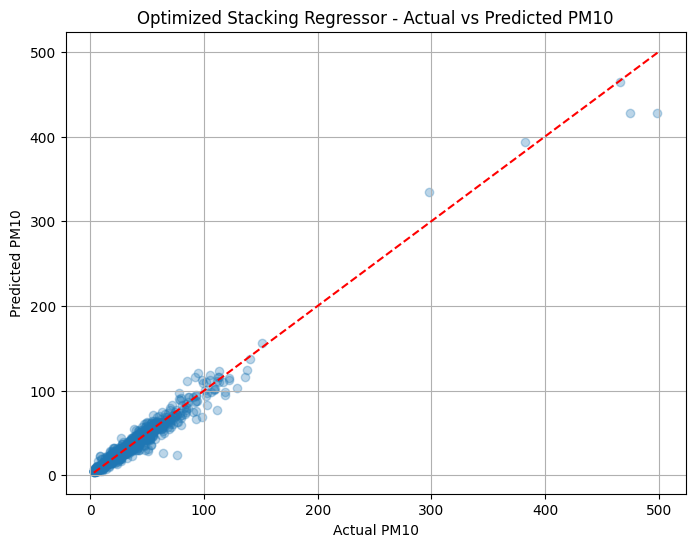

RMSE: 6.504194514624182
MAE: 3.978230706034237
R2 Score: 0.9659913937180561
MRE (Mean Relative Error): 3.26%


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# 예측
y_pred = stacking_model.predict(X_test)

# RMSE 수동 계산
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# 기타 지표
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# MRE 계산 (0으로 나눔 방지 포함)
relative_error = np.where(y_test != 0, (y_pred - y_test) / y_test, 0)
mre = np.mean(relative_error) * 100

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual PM10")
plt.ylabel("Predicted PM10")
plt.title("Optimized Stacking Regressor - Actual vs Predicted PM10")
plt.grid(True)
plt.show()

# 출력
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)
print("MRE (Mean Relative Error): {:.2f}%".format(mre))


# 모델 불러와서 여기서부터 돌리면 됩니다(가상의 도시숲 불러오기)

In [ ]:
import joblib

model_path = '/content/stacking_model_final_average.pkl'

# 저장된 모델 불러오기
stacking_model = joblib.load(model_path)
print("✅ 모델이 성공적으로 로드되었습니다.")


✅ 모델이 성공적으로 로드되었습니다.


In [ ]:
row = df[df['ymdt'] == 202403290800]
columns_to_add = row.iloc[0, -2:]  # CO2 컬럼 두 개 (마지막 두 칼럼)
columns_to_add.index = ["Gas_Co2", "Elec_Co2"]

for i in range(1, 8):
    input_path = f'/content/drive/MyDrive/fake_uf_data/cleaned_test_h{i}_202403290800.csv'
    scaled_path = f'/content/cleaned_test_h{i}_202403290800_scaled_final5.csv'

    target_df = pd.read_csv(input_path)

    # CO2 값 추가
    for col, val in columns_to_add.items():
        target_df[col] = val

    # 누락 컬럼 0으로 채우기 (연속형+이진형)
    for col in continuous_cols + binary_cols:
        if col not in target_df.columns:
            target_df[col] = 0

    # 연속형만 스케일링
    continuous_scaled = scaler.transform(target_df[continuous_cols])
    continuous_scaled_df = pd.DataFrame(continuous_scaled, columns=continuous_cols, index=target_df.index)

    # 이진형은 그대로 유지
    binary_df = target_df[binary_cols]

    # 합치기
    scaled_df = pd.concat([continuous_scaled_df, binary_df], axis=1)

    # 모델이 기대하는 컬럼 순서 맞추기
    scaled_df = scaled_df.reindex(columns=expected_columns, fill_value=0)

    # 저장
    scaled_df.to_csv(scaled_path, index=False)
    print(f"✅ h{i} 전체 칼럼 스케일링 완료 및 저장: {scaled_path}")

    # 예측
    y_pred = stacking_model.predict(scaled_df)
    mean_y = float(y_pred.mean())
    result.append(mean_y)

print("최종 예측 결과:", result)


✅ h1 전체 칼럼 스케일링 완료 및 저장: /content/cleaned_test_h1_202403290800_scaled_final5.csv
✅ h2 전체 칼럼 스케일링 완료 및 저장: /content/cleaned_test_h2_202403290800_scaled_final5.csv
✅ h3 전체 칼럼 스케일링 완료 및 저장: /content/cleaned_test_h3_202403290800_scaled_final5.csv
✅ h4 전체 칼럼 스케일링 완료 및 저장: /content/cleaned_test_h4_202403290800_scaled_final5.csv
✅ h5 전체 칼럼 스케일링 완료 및 저장: /content/cleaned_test_h5_202403290800_scaled_final5.csv
✅ h6 전체 칼럼 스케일링 완료 및 저장: /content/cleaned_test_h6_202403290800_scaled_final5.csv
✅ h7 전체 칼럼 스케일링 완료 및 저장: /content/cleaned_test_h7_202403290800_scaled_final5.csv
최종 예측 결과: [282.80340576171875, 282.724365234375, 282.9637145996094, 278.7670593261719, 284.44793701171875, 278.8167724609375, 282.4032287597656, 282.80340576171875, 282.724365234375, 282.9637145996094, 278.7670593261719, 284.44793701171875, 278.8167724609375, 282.4032287597656, 282.80340576171875, 282.724365234375, 282.9637145996094, 278.7670593261719, 284.44793701171875, 278.8167724609375, 282.4032287597656, 282.80340576171875, 

In [ ]:
print(result)

[282.80340576171875, 282.724365234375, 282.9637145996094, 278.7670593261719, 284.44793701171875, 278.8167724609375, 282.4032287597656, 282.80340576171875, 282.724365234375, 282.9637145996094, 278.7670593261719, 284.44793701171875, 278.8167724609375, 282.4032287597656, 282.80340576171875, 282.724365234375, 282.9637145996094, 278.7670593261719, 284.44793701171875, 278.8167724609375, 282.4032287597656]


In [ ]:
decreasing = []
for a in result :
  a = 439.56 - a
  decreasing.append(a)

print(decreasing)
max_value = max(decreasing)
max_index = decreasing.index(max_value)+1
print(f"가장 큰 평균 감소값: {max_value}, 위치: h{max_index}")

[156.75659423828125, 156.835634765625, 156.59628540039063, 160.79294067382813, 155.11206298828125, 160.7432275390625, 157.15677124023438, 156.75659423828125, 156.835634765625, 156.59628540039063, 160.79294067382813, 155.11206298828125, 160.7432275390625, 157.15677124023438, 156.75659423828125, 156.835634765625, 156.59628540039063, 160.79294067382813, 155.11206298828125, 160.7432275390625, 157.15677124023438]
가장 큰 평균 감소값: 160.79294067382813, 위치: h4


In [ ]:
model_path = '/content/drive/MyDrive/stacking_model_01_updated.pkl'
joblib.dump(stacking_model, model_path)
print("✅ 모델이 내 드라이브 루트에 저장됐어요:", model_path)


✅ 모델이 내 드라이브 루트에 저장됐어요: /content/drive/MyDrive/stacking_model_01_updated.pkl
